In [1]:
!pip install Rbeast

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.0 MB/s eta 0:00:00a 0:00:01


In [2]:
import Rbeast as rb

Help on function load_example in module Rbeast.load_example:

load_example(name)
    Possible example datasets are:
      nile       : annual streamflow of the River Nile from 1871
      googletrend: monthly Google search popularity of the keyword 'beach'
      yellowstone: biweekly NDVI (greenness) of a Yellowstone site
      ohio       : satelite reflectanes and NDVI of an Ohio site
      co2        : monthly CO2 concentrations
      covid19    : weekly  new cases and deaths from COVID-19
      simdata    : a 774x3 matrix: three time series of length 774 
      imagestack : stacked images of NDVI over a small area

Help on function beast in module Rbeast.beast:

beast(Y, start=1, deltat=1, season='harmonic', period=nan, scp_minmax=[0, 10], sorder_minmax=[0, 5], sseg_minlength=None, sseg_leftmargin=None, sseg_rightmargin=None, tcp_minmax=[0, 10], torder_minmax=[0, 1], tseg_minlength=None, tseg_leftmargin=None, tseg_rightmargin=None, method='bayes', detrend=False, deseasonalize=False, 


Model fitted:  Y =  trend + error 

INFO: To supress messages, set print_param/print_warning/print_progresss = 0 in beast() and beast_irreg()
INFO: To supress messages, Set extra.printParameter/printWarning/printProgress = 0 in beast123()
INFO: To supress all messaages, set quiet=1 in beast() and beast_irreg() or extra.quiet=1 in beast123()

#--------------------------------------------------#
#       Brief summary of Input Data                #
#--------------------------------------------------#
Data Dimension: One signal of length 100
IsOrdered     : Yes, ordered in time
IsRegular     : Yes, evenly spaced at interval of  1 (unknown unit)
hasSeasonCmpnt: False | no periodic or seasonal component. The model Y=Trend+Error is fitted.
HasOutlierCmpt: False | If true, Y=Trend+Outlier+Error (experimental) is fitted instead of Y=Trend+Error 
Detrend       : False | If true, remove a global trend component before running BEAST & add it back after BEAST
MissingValue  : NaN  flagged as missin

Object of 9 field(s):

 time        : [100 float32] 
 data        : [100 float32] 
 marg_lik    : -173.89 
 R2          : 0.448821 
 RMSE        : 125.261 
 sig2        : 16845.3 
 trend       : [ 1 object with 18 fields] 
               ncp            : 1.82958 
               ncp_median     : 2 
               ncp_mode       : 1 
               ncp_pct90      : 3 
               ncp_pct10      : 1 
               ncpPr          : [11 float32] 
               cpOccPr        : [100 float32] 
               order          : [100 float32] 
               cp             : [10 float32] 
               cpPr           : [10 float32] 
               cpAbruptChange : [10 float32] 
               cpCI           : [10x2 float32] 
               Y              : [100 float32] 
               SD             : [100 float32] 
               slp            : [100 float32] 
               slpSD          : [100 float32] 
               slpSgnPosPr    : [100 float32] 
               slpSgnZeroPr   : [10

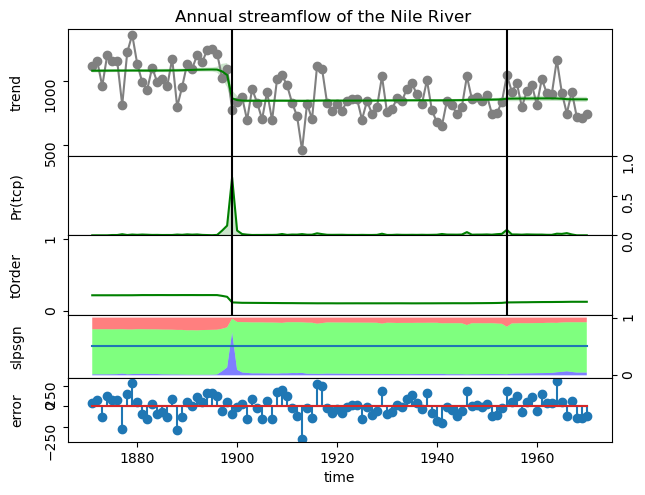

In [3]:
nile, year = rb.load_example('nile')                     # nile is a 1d Python array or numpy vector
o          = rb.beast( nile, start=1871, season='none')  # season='none' bcz the data has no seasonal/periodic component
rb.plot(o, title='Annual streamflow of the Nile River')
rb.print(o)

# Print a list of fields in the output variable (e.g, o.data, o.RMSE, o.trend.cp, o.time, and o.tend.cpOccPr)
# Check the R manual for expalanations of the output (https://cran.r-project.org/web/packages/Rbeast/Rbeast.pdf) 
o                                                        # this is equivalent to "print(o)"                                    


Model fitted:  Y =  trend + season + error 

INFO: To supress messages, set print_param/print_warning/print_progresss = 0 in beast() and beast_irreg()
INFO: To supress messages, Set extra.printParameter/printWarning/printProgress = 0 in beast123()
INFO: To supress all messaages, set quiet=1 in beast() and beast_irreg() or extra.quiet=1 in beast123()

#--------------------------------------------------#
#       Brief summary of Input Data                #
#--------------------------------------------------#
Data Dimension: One signal of length 221
IsOrdered     : Yes, ordered in time
IsRegular     : Yes, evenly spaced at interval of  0.0833333 (unknown unit)
HasSeasonCmpnt: True  | period = 1 (unknown unit). The model 'Y=Trend+Season+Error' is fitted.
              : Num_of_DataPoints_per_Period = period/deltaTime = 1/0.0833333 = 12
HasOutlierCmpt: False | If true, Y=Trend+Season+Outlier+Error fitted instead of Y=Trend+Season+Error
Deseasonalize : False | If true, remove a global seaso

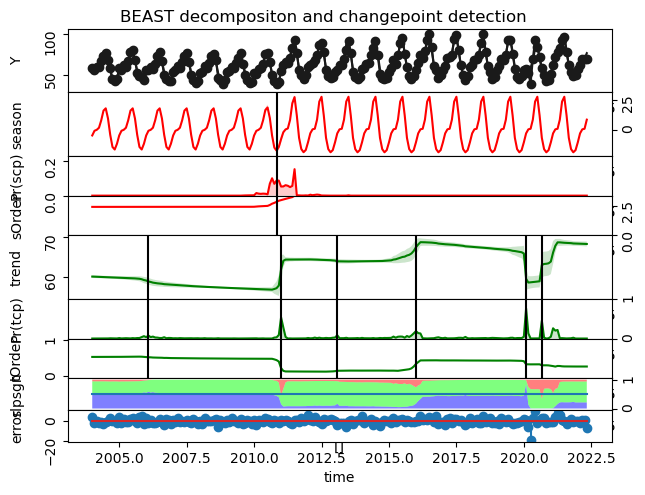

In [4]:
beach, year = rb.load_example('googletrend')
o = rb.beast(beach, start= 2004, deltat=1/12, period = 1.0)       # the time unit is uknown or arbitrary
o = rb.beast(beach, start= 2004, deltat=1/12, period ='1.0 year') # the time unit is fractional year
rb.plot(o)
rb.print(o)